<a href="https://colab.research.google.com/github/Aritraghoshdastidar/GitRAG/blob/main/GitRag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install Dependencies                               ║
# ║  Run this cell ONCE. Colab will restart. Then run Cell 2+.  ║
# ╚══════════════════════════════════════════════════════════════╝
import subprocess, sys

packages = [
    "langchain",
    "langchain-community",
    "langchain-core",
    "langchain-huggingface",
    "langchain-text-splitters",
    "chromadb",
    "sentence-transformers",
    "gitpython",
    "tiktoken",
    "groq",
    "gradio",
    "rouge-score",
    "scikit-learn",
    "numpy",
    "pandas",
    "matplotlib",
    "tabulate",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

print("✅ All packages installed. Please restart the Colab runtime now.")
print("   Runtime → Restart session  (then run from Cell 2 downward)")

✅ All packages installed. Please restart the Colab runtime now.
   Runtime → Restart session  (then run from Cell 2 downward)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports & Global Configuration                     ║
# ╚══════════════════════════════════════════════════════════════╝
import os, shutil, sys, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict
import getpass

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.prompts import PromptTemplate
from groq import Groq
from rouge_score import rouge_scorer
from sklearn.metrics.pairwise import cosine_similarity

CFG = {
    # Models
    "llm_model":      "llama-3.3-70b-versatile",
    "embed_model":    "sentence-transformers/all-MiniLM-L6-v2",

    # Paths
    "chroma_dir":     "/tmp/chroma_rag_db",
    "codebase_dir":   "/tmp/codebase",

    # Retrieval
    "top_k":          5,
    "chunk_size":     800,
    "chunk_overlap":  150,

    # ── FIXED: L2 distances from ChromaDB with all-MiniLM-L6-v2
    #    range from ~1.0 (very close) to ~1.8+ (unrelated).
    #    Previous value of 0.55 was for cosine similarity, NOT L2.
    #    Formula: L2 = sqrt(2 - 2*cosine_sim), so:
    #      cosine_sim = 0.30 → L2 ≈ 1.18   (somewhat relevant)
    #      cosine_sim = 0.10 → L2 ≈ 1.34   (loosely relevant)
    #      cosine_sim = 0.00 → L2 ≈ 1.41   (unrelated)
    #    Setting 1.40 captures anything with cosine_sim > ~0.02
    "dist_threshold": 1.40,

    # LLM
    "temperature":    0.2,
    "max_tokens":     2048,
}

CODE_EXTENSIONS: Dict[str, str] = {
    ".py":   "python",    ".js":   "javascript", ".ts":   "typescript",
    ".jsx":  "javascript",".tsx":  "typescript",  ".java": "java",
    ".cpp":  "cpp",       ".c":    "cpp",         ".h":    "cpp",
    ".go":   "go",        ".rb":   "ruby",        ".rs":   "rust",
    ".cs":   "csharp",    ".php":  "php",         ".kt":   "kotlin",
    ".swift":"swift",     ".sh":   "shell",       ".sql":  "sql",
}

IGNORE_DIRS = {
    "node_modules", ".git", "dist", "build", "__pycache__",
    ".next", "venv", ".venv", "coverage", ".cache",
    ".idea", ".vscode", "public", "assets", "static",
    "migrations", "fixtures", "test_data",
}

STATE: Dict = {
    "vectordb":   None,
    "embeddings": None,
    "loaded":     False,
    "source":     "",
    "num_files":  0,
    "num_chunks": 0,
}

G = "\033[92m"; Y = "\033[93m"; R = "\033[91m"
B = "\033[94m"; M = "\033[95m"; RESET = "\033[0m"

print(f"{G}✅ Configuration loaded{RESET}")
print(f"   LLM            : {CFG['llm_model']}")
print(f"   Embedder       : {CFG['embed_model']}")
print(f"   Chunk          : {CFG['chunk_size']} chars / {CFG['chunk_overlap']} overlap")
print(f"   Top-K          : {CFG['top_k']}")
print(f"   Dist threshold : {CFG['dist_threshold']}  (L2, not cosine)")

✅ Configuration loaded
   LLM            : llama-3.3-70b-versatile
   Embedder       : sentence-transformers/all-MiniLM-L6-v2
   Chunk          : 800 chars / 150 overlap
   Top-K          : 5
   Dist threshold : 1.4  (L2, not cosine)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Groq API Key                                       ║
# ╚══════════════════════════════════════════════════════════════╝

def get_api_key() -> str:
    """
    Looks for GROQ_API_KEY in:
      1. OS environment (set in Colab Secrets or export)
      2. Colab userdata store
      3. Interactive prompt (fallback)
    """
    key = os.environ.get("GROQ_API_KEY", "")
    if key:
        return key

    # Try Colab Secrets (Colab ≥ 2024)
    try:
        from google.colab import userdata
        key = userdata.get("GROQ_API_KEY")
        if key:
            return key
    except Exception:
        pass

    # Interactive fallback
    key = getpass.getpass("🔑 Enter your Groq API key: ")
    return key.strip()


GROQ_API_KEY = get_api_key()
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# Verify the key is usable
try:
    _test_client = Groq(api_key=GROQ_API_KEY)
    _test_resp = _test_client.chat.completions.create(
        model=CFG["llm_model"],
        messages=[{"role": "user", "content": "Reply with the single word: OK"}],
        max_tokens=5,
    )
    assert "ok" in _test_resp.choices[0].message.content.lower()
    print(f"{G}✅ Groq API key verified — model responding correctly{RESET}")
except Exception as exc:
    print(f"{R}❌ Groq API key test failed: {exc}{RESET}")
    print("   Check your key at https://console.groq.com/keys")

🔑 Enter your Groq API key: ··········
✅ Groq API key verified — model responding correctly


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Data Ingestion Layer                               ║
# ║  Accepts: GitHub URL  OR  absolute local folder path         ║
# ╚══════════════════════════════════════════════════════════════╝

def _clean_dir(path: str) -> None:
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def ingest_codebase(source: str) -> str:
    """
    Clone or locate the codebase.
    Returns the local folder path where source files live.
    Raises RuntimeError / FileNotFoundError on failure.
    """
    source = source.strip().rstrip("/")

    if source.startswith("http://") or source.startswith("https://"):
        repo_name    = source.split("/")[-1].replace(".git", "")
        clone_target = os.path.join(CFG["codebase_dir"], repo_name)
        _clean_dir(CFG["codebase_dir"])

        print(f"🔄 Cloning {source} …")
        ret = os.system(f"git clone --depth=1 {source} {clone_target} 2>&1")
        if ret != 0:
            raise RuntimeError(
                "Git clone failed. Verify the URL is a public repository "
                "and that git is available."
            )
        print(f"{G}✅ Cloned → {clone_target}{RESET}")
        return clone_target

    else:
        if not os.path.isdir(source):
            raise FileNotFoundError(f"Local path not found: {source}")
        print(f"{G}✅ Using local path: {source}{RESET}")
        return source


def load_code_files(directory: str) -> List:
    """
    Walk `directory`, load every supported source file into
    LangChain Documents with language + filename metadata.
    Skips files > 200 KB and binary/unreadable files.
    """
    MAX_BYTES = 200_000
    docs      = []
    skipped   = 0

    for root, dirs, files in os.walk(directory):
        # Prune ignored directories in-place
        dirs[:] = [d for d in dirs if d not in IGNORE_DIRS and not d.startswith(".")]

        for fname in files:
            ext = Path(fname).suffix.lower()
            if ext not in CODE_EXTENSIONS:
                continue

            fpath = os.path.join(root, fname)
            try:
                if os.path.getsize(fpath) > MAX_BYTES:
                    skipped += 1
                    continue
                loader = TextLoader(fpath, encoding="utf-8", autodetect_encoding=True)
                loaded = loader.load()
                for doc in loaded:
                    doc.metadata["language"] = CODE_EXTENSIONS[ext]
                    doc.metadata["filename"] = fname
                    doc.metadata["filepath"] = fpath
                    doc.metadata["source"]   = fpath
                docs.extend(loaded)
            except Exception:
                skipped += 1

    print(f"📄 Loaded {len(docs)} files  |  ⏭ skipped {skipped} (too large / unreadable)")
    return docs


print(f"{G}✅ Ingestion functions defined{RESET}")

✅ Ingestion functions defined


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Text Chunking + Embedding + ChromaDB               ║
# ╚══════════════════════════════════════════════════════════════╝
import chromadb
from chromadb.config import Settings

def _get_embeddings() -> HuggingFaceEmbeddings:
    if STATE["embeddings"] is None:
        print("⏳ Loading sentence-transformer embedding model …")
        STATE["embeddings"] = HuggingFaceEmbeddings(
            model_name=CFG["embed_model"],
            model_kwargs={"device": "cpu"},
            encode_kwargs={"normalize_embeddings": True},
        )
        print(f"{G}✅ Embedding model ready{RESET}")
    return STATE["embeddings"]


def build_vector_db(code_path: str) -> Tuple[int, int]:
    # ── Dispose existing Chroma client safely ────────────────────
    if STATE["vectordb"] is not None:
        try:
            STATE["vectordb"]._client._system.stop()
        except Exception:
            pass
        STATE["vectordb"] = None

    raw_docs = load_code_files(code_path)
    if not raw_docs:
        raise ValueError(
            "No supported code files found. Check the path / URL and "
            "that the repository contains .py / .js / .ts / .java / etc. files."
        )

    # ── Chunking ─────────────────────────────────────────────────
    splitter = RecursiveCharacterTextSplitter(
        chunk_size    = CFG["chunk_size"],
        chunk_overlap = CFG["chunk_overlap"],
        separators    = ["\nclass ", "\ndef ", "\n\n", "\n", " ", ""],
    )
    splits = splitter.split_documents(raw_docs)
    print(f"✂️  {len(splits)} chunks from {len(raw_docs)} files")

    # ── Wipe + recreate the chroma directory with full permissions
    chroma_dir = CFG["chroma_dir"]
    if os.path.exists(chroma_dir):
        shutil.rmtree(chroma_dir)
    os.makedirs(chroma_dir, mode=0o777, exist_ok=True)

    # Explicitly chmod after creation (makedirs mode is masked by umask)
    os.chmod(chroma_dir, 0o777)

    # ── Build ChromaDB with explicit writable settings ────────────
    emb = _get_embeddings()
    print("⏳ Building ChromaDB vector store …")
    t0 = time.time()

    chroma_client = chromadb.PersistentClient(
        path=chroma_dir,
        settings=Settings(
            anonymized_telemetry=False,
            allow_reset=True,
            is_persistent=True,
        ),
    )

    STATE["vectordb"] = Chroma(
        client=chroma_client,
        collection_name="codebase",
        embedding_function=emb,
    )

    # Add documents in batches to avoid memory spikes
    BATCH = 100
    for i in range(0, len(splits), BATCH):
        batch = splits[i : i + BATCH]
        STATE["vectordb"].add_documents(batch)
        print(f"   indexed {min(i + BATCH, len(splits))}/{len(splits)} chunks …", end="\r")

    elapsed = time.time() - t0
    count   = STATE["vectordb"]._collection.count()
    print(f"\n{G}✅ Vector DB ready — {count} vectors in {elapsed:.1f}s{RESET}")

    STATE["loaded"]     = True
    STATE["source"]     = code_path
    STATE["num_files"]  = len(raw_docs)
    STATE["num_chunks"] = len(splits)
    return len(raw_docs), len(splits)


print(f"{G}✅ Vector DB functions defined{RESET}")

✅ Vector DB functions defined


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Language Detection + Context Retrieval             ║
# ╚══════════════════════════════════════════════════════════════╝

# Error-pattern keywords per language used to infer query language
_LANG_PATTERNS: Dict[str, List[str]] = {
    "python":     [
        "traceback", "nameerror", "indentationerror", "syntaxerror",
        "attributeerror", "importerror", "valueerror", "typeerror:",
        "keyerror", "indexerror", "zerodivisionerror", ".py\"", ".py'",
        "modulenotfounderror", "recursionerror",
    ],
    "javascript": [
        "typeerror", "referenceerror", "undefined is not", "is not defined",
        "cannot read propert", "uncaught", ".js:", "syntaxerror: unexpected",
        "rangeerror",
    ],
    "typescript": ["ts(", "type '", ".ts:", "typescript", "cannot find name"],
    "java":       [
        "nullpointerexception", "classnotfoundexception",
        "arrayindexoutofboundsexception", "exception in thread",
        "stackoverflowerror", ".java:",
    ],
    "cpp":        [
        "segmentation fault", "undefined reference", "core dumped",
        "undefined symbol", ".cpp:", ".c:", "lnk2019",
    ],
    "go":         ["panic:", "goroutine ", "runtime error:", ".go:"],
    "rust":       ["thread 'main' panicked", "borrow checker", "lifetime", ".rs:"],
    "csharp":     ["system.nullreferenceexception", "unhandled exception:", ".cs:"],
}


def detect_query_language(text: str) -> Optional[str]:
    """Return the most likely language from error text, or None."""
    lower = text.lower()
    for lang, keywords in _LANG_PATTERNS.items():
        if any(kw in lower for kw in keywords):
            return lang
    return None


def retrieve_context(query: str, k: Optional[int] = None) -> Tuple[List, List[str]]:
    """
    Retrieve the top-k most relevant code chunks.
    Applies language pre-filtering when the query language is detectable.
    Falls back to unfiltered results if language filter leaves nothing.

    Returns:
        docs           – list of LangChain Document objects
        retrieval_info – list of human-readable strings with source + score
    """
    if STATE["vectordb"] is None:
        raise RuntimeError("No vector DB loaded. Ingest a codebase first.")

    k       = k or CFG["top_k"]
    lang    = detect_query_language(query)
    # Fetch 3× more than needed so language filter has candidates
    raw_res = STATE["vectordb"].similarity_search_with_score(query, k=k * 3)

    # ── Language filter ─────────────────────────────────────────
    filtered = (
        [(d, s) for d, s in raw_res if d.metadata.get("language") == lang]
        if lang else raw_res
    )
    if not filtered:          # fallback if filter too aggressive
        filtered = raw_res

    # ── Distance filter + top-k cap ─────────────────────────────
    filtered = filtered[:k]

    docs           = [d for d, _ in filtered]
    retrieval_info = [
        f"[{i+1}] {d.metadata.get('filename','?')}  "
        f"lang={d.metadata.get('language','?')}  "
        f"dist={s:.4f}"
        for i, (d, s) in enumerate(filtered)
    ]
    return docs, retrieval_info


print(f"{G}✅ Language detection + retrieval defined{RESET}")

✅ Language detection + retrieval defined


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Prompt Template + LLM Query + Confidence Parser   ║
# ╚══════════════════════════════════════════════════════════════╝
import re

SYSTEM_PROMPT = """\
You are a senior software engineer specialising in code debugging.
You receive:
  • An error message or a developer question about a codebase
  • Relevant code snippets retrieved from that codebase

Your job is to provide a clear, accurate, structured debugging analysis.
Never make up code that was not in the provided context.
If the context is insufficient, say so explicitly.
"""

USER_TEMPLATE = """\
## Error / Question
{error}

## Retrieved Code Context
{context}

## Required Response Format

**1. Error Type**
Classify the error (e.g. NameError, NullPointerException, logic bug, race condition).

**2. Root Cause**
Explain *why* the error occurs, referencing specific lines or patterns from the context above.

**3. Affected Code**
Name the specific file(s) and function(s) involved.

**4. Suggested Fix**
Provide a concrete corrected code snippet or a numbered fix plan.

**5. Confidence Level**
State one of: High / Medium / Low
Then provide a numeric self-assessment score between 0.0 and 1.0 in this exact format:
  Score: 0.XX
Justify based on how well the retrieved context matches the error.

**6. Prevention Tip**
One sentence on how to avoid this class of bug in future.
"""

_prompt_template = PromptTemplate(
    input_variables=["error", "context"],
    template=USER_TEMPLATE,
)

_groq_client = Groq(api_key=GROQ_API_KEY)


# ── Confidence extraction ────────────────────────────────────────

def _extract_confidence(answer: str) -> Tuple[str, float]:
    """
    Parse the LLM's Confidence Level section.
    1. Tries to read 'Score: 0.XX' that the prompt explicitly asks for.
    2. Falls back to keyword matching (High / Medium / Low).
    Returns (label, numeric_score).
    """
    # ── Try to find explicit Score: 0.XX ────────────────────────
    score_match = re.search(r"score\s*[:\-]\s*(0?\.\d+|1\.0)", answer, re.IGNORECASE)
    if score_match:
        numeric = float(score_match.group(1))
        numeric = max(0.0, min(1.0, numeric))   # clamp to [0, 1]
        if numeric >= 0.70:
            label = "High"
        elif numeric >= 0.45:
            label = "Medium"
        else:
            label = "Low"
        return label, round(numeric, 2)

    # ── Fallback: keyword search near the Confidence section ────
    # Find text around section 5
    section_match = re.search(
        r"\*\*5\..*?confidence.*?\*\*(.*?)(?:\*\*6\.|$)",
        answer, re.IGNORECASE | re.DOTALL
    )
    search_text = section_match.group(1).lower() if section_match else answer.lower()

    if "high" in search_text:
        return "High", 0.82
    elif "medium" in search_text or "moderate" in search_text:
        return "Medium", 0.55
    elif "low" in search_text:
        return "Low", 0.28
    return "Unknown", 0.50


def _confidence_html(label: str, score: float) -> str:
    """
    Render a styled HTML confidence gauge for the Gradio UI.
    """
    colour = {
        "High":    "#16a34a",   # green
        "Medium":  "#d97706",   # amber
        "Low":     "#dc2626",   # red
        "Unknown": "#6b7280",   # grey
    }.get(label, "#6b7280")

    pct      = int(round(score * 100))
    bg_light = {
        "High":    "#f0fdf4",
        "Medium":  "#fffbeb",
        "Low":     "#fef2f2",
        "Unknown": "#f9fafb",
    }.get(label, "#f9fafb")

    return f"""
    <div style="
        padding: 14px 18px;
        border: 1px solid {colour}40;
        border-left: 4px solid {colour};
        border-radius: 8px;
        background: {bg_light};
        font-family: sans-serif;
    ">
      <div style="font-size:12px; color:#6b7280; text-transform:uppercase;
                  letter-spacing:0.05em; margin-bottom:4px;">
        Model Confidence Score
      </div>
      <div style="display:flex; align-items:baseline; gap:10px; margin-bottom:8px;">
        <span style="font-size:36px; font-weight:800; color:{colour}; line-height:1;">
          {pct}%
        </span>
        <span style="font-size:16px; font-weight:600; color:{colour};">
          {label}
        </span>
      </div>
      <!-- Progress bar -->
      <div style="background:#e5e7eb; border-radius:999px; height:10px; width:100%;">
        <div style="
            background: linear-gradient(90deg, {colour}99, {colour});
            height: 10px;
            border-radius: 999px;
            width: {pct}%;
            transition: width 0.4s ease;
        "></div>
      </div>
      <div style="display:flex; justify-content:space-between;
                  font-size:10px; color:#9ca3af; margin-top:3px;">
        <span>0%</span><span>50%</span><span>100%</span>
      </div>
    </div>
    """


def query_llm(error_query: str, context_docs: List) -> str:
    """Format the prompt and call the Groq LLM. Returns the raw answer string."""
    context_text = "\n\n".join([
        f"### File: {d.metadata.get('filename', 'unknown')} "
        f"[{d.metadata.get('language', '?')}]\n"
        f"```\n{d.page_content}\n```"
        for d in context_docs
    ])
    user_msg = _prompt_template.format(error=error_query, context=context_text)
    response = _groq_client.chat.completions.create(
        model       = CFG["llm_model"],
        temperature = CFG["temperature"],
        max_tokens  = CFG["max_tokens"],
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_msg},
        ],
    )
    return response.choices[0].message.content.strip()


def run_debugging_query(error_query: str) -> Tuple[str, str, List, str, float]:
    """
    Full RAG pipeline.
    Returns: (answer, sources_text, docs, confidence_label, confidence_score)
    Raises RuntimeError if no codebase loaded, ValueError if query empty.
    """
    error_query = error_query.strip()
    if not error_query:
        raise ValueError("Query is empty.")
    if not STATE["loaded"]:
        raise RuntimeError("No codebase loaded. Load one first.")

    docs, info           = retrieve_context(error_query)
    answer               = query_llm(error_query, docs)
    conf_label, conf_num = _extract_confidence(answer)
    sources              = "\n".join(info)
    return answer, sources, docs, conf_label, conf_num


print(f"{G}✅ LLM prompt + query engine + confidence parser defined{RESET}")

✅ LLM prompt + query engine + confidence parser defined


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Gradio User Interface                              ║
# ╚══════════════════════════════════════════════════════════════╝
import gradio as gr


def ui_load_codebase(source: str) -> str:
    if not source.strip():
        return "⚠️ Please enter a GitHub URL or absolute local folder path."
    try:
        code_path         = ingest_codebase(source)
        n_files, n_chunks = build_vector_db(code_path)
        return (
            f"✅ Codebase indexed successfully!\n\n"
            f"📁  Source  : {source}\n"
            f"📄  Files   : {n_files}\n"
            f"✂️   Chunks  : {n_chunks}\n"
            f"🔢  Vectors : {STATE['vectordb']._collection.count()}\n\n"
            f"Switch to the 🔍 Debug tab and ask your first question."
        )
    except Exception as exc:
        return f"❌ Error during indexing:\n{exc}"


def ui_debug_query(error_query: str) -> Tuple[str, str, str]:
    """
    Returns: (answer_markdown, sources_text, confidence_html)
    """
    if not STATE["loaded"]:
        empty_conf = _confidence_html("Unknown", 0.50)
        return (
            "⚠️ No codebase loaded yet.\nGo to the 📁 Load Codebase tab first.",
            "",
            empty_conf,
        )
    try:
        answer, sources, _, conf_label, conf_score = run_debugging_query(error_query)
        conf_html = _confidence_html(conf_label, conf_score)
        return answer, sources, conf_html
    except Exception as exc:
        err_conf = _confidence_html("Unknown", 0.0)
        return f"❌ Error: {exc}", "", err_conf


# ── Gradio layout ────────────────────────────────────────────────

with gr.Blocks(
    title="RAG Codebase Debugger",
    theme=gr.themes.Soft(),
    css="""
        .sources-box textarea { font-family: monospace; font-size: 0.82em; }
        .answer-col { min-height: 300px; }
    """,
) as demo:

    gr.Markdown(
        """
        # 🐛 Context-Aware Codebase Debugging Assistant
        **Stack**: LangChain · ChromaDB · HuggingFace Embeddings · Groq LLaMA 3.3 70B · Gradio

        Provide a GitHub URL or local path → index the codebase → paste an error or ask a question.
        """
    )

    # ── Tab 1: Load ──────────────────────────────────────────────
    with gr.Tab("📁 Load Codebase"):
        gr.Markdown("### Step 1 — Index your codebase")
        source_box = gr.Textbox(
            label="GitHub URL or local absolute path",
            placeholder=(
                "https://github.com/username/repo-name\n"
                "— OR —\n"
                "/path/to/local/project"
            ),
            lines=2,
        )
        load_btn    = gr.Button("🚀 Load & Index", variant="primary", size="lg")
        load_status = gr.Textbox(label="Status", lines=9, interactive=False)
        load_btn.click(fn=ui_load_codebase, inputs=source_box, outputs=load_status)

    # ── Tab 2: Debug ─────────────────────────────────────────────
    with gr.Tab("🔍 Debug / Ask"):
        gr.Markdown("### Step 2 — Paste an error or ask a code question")
        error_box = gr.Textbox(
            label="Error Message or Question",
            placeholder=(
                "Paste a full Python/Java/JS traceback, or ask something like:\n"
                "'Why does the login function raise a KeyError on user_id?'\n"
                "'What does process_payment() do and where can it fail?'"
            ),
            lines=9,
        )
        debug_btn = gr.Button("🧠 Analyze", variant="primary", size="lg")

        # ── Output row: analysis | right column (confidence + sources)
        with gr.Row():
            with gr.Column(scale=3, elem_classes=["answer-col"]):
                answer_box = gr.Markdown(
                    label="Analysis",
                    value="*Analysis will appear here after you click Analyze.*",
                )
            with gr.Column(scale=1):
                # ── Confidence gauge (HTML component) ──────────
                confidence_box = gr.HTML(
                    value=_confidence_html("Unknown", 0.50),
                    label="Confidence Score",
                )
                gr.Markdown("---")
                sources_box = gr.Textbox(
                    label="📊 Retrieved Chunks (file | lang | dist)",
                    lines=10,
                    interactive=False,
                    elem_classes=["sources-box"],
                )

        debug_btn.click(
            fn=ui_debug_query,
            inputs=error_box,
            outputs=[answer_box, sources_box, confidence_box],
        )

    # ── Tab 3: System Info ───────────────────────────────────────
    with gr.Tab("ℹ️ System Info"):
        def get_system_info() -> str:
            vdb    = STATE["vectordb"]
            n_vecs = vdb._collection.count() if vdb else "—"
            return (
                f"**LLM**             : `{CFG['llm_model']}`\n"
                f"**Embedder**        : `{CFG['embed_model']}`\n"
                f"**Chunk size**      : {CFG['chunk_size']} chars ({CFG['chunk_overlap']} overlap)\n"
                f"**Top-K**           : {CFG['top_k']}\n"
                f"**Dist threshold**  : {CFG['dist_threshold']} (L2)\n"
                f"**Temperature**     : {CFG['temperature']}\n\n"
                f"---\n"
                f"**Source**          : {STATE.get('source', '—')}\n"
                f"**Files loaded**    : {STATE.get('num_files', '—')}\n"
                f"**Chunks**          : {STATE.get('num_chunks', '—')}\n"
                f"**Vectors**         : {n_vecs}\n\n"
                f"---\n"
                f"### Pipeline\n"
                f"Input → Language Detection → ChromaDB Similarity Search\n"
                f"→ Top-{CFG['top_k']} Code Chunks → Groq LLaMA 3.3 70B → Structured Answer\n\n"
                f"### Supported Languages\n"
                f"Python · JavaScript · TypeScript · Java · C/C++ · Go · Ruby · "
                f"Rust · C# · PHP · Kotlin · Swift · SQL · Shell"
            )

        info_btn    = gr.Button("🔄 Refresh Info")
        info_output = gr.Markdown(get_system_info())
        info_btn.click(fn=get_system_info, outputs=info_output)

demo.launch(debug=True)

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Evaluation Test Dataset                            ║
# ║  References are now detailed enough to yield meaningful      ║
# ║  ROUGE-L scores against 250-word generated answers.          ║
# ╚══════════════════════════════════════════════════════════════╝

TEST_CASES: List[Dict] = [

    # ── Python ─────────────────────────────────────────────────
    {
        "query": "NameError: name 'db' is not defined",
        "reference": (
            "The NameError indicates the variable 'db' is being referenced before it has been "
            "defined or imported in the current scope. This commonly happens when the database "
            "connection object is created conditionally or inside a function that was never called, "
            "making 'db' unavailable at the point of use. To fix this, ensure the database "
            "connection is initialised at module level or passed as a parameter. Check all code "
            "paths to confirm 'db' is always assigned before being accessed. If the variable is "
            "meant to be global, use the global keyword or restructure to avoid relying on global state."
        ),
        "must_contain": ["NameError", "defined", "variable", "scope", "initialise"],
        "category": "Python",
    },
    {
        "query": (
            "TypeError: unsupported operand type(s) for +: 'int' and 'str'\n"
            "Traceback (most recent call last):\n"
            "  File \"app.py\", line 42, in calculate_total\n"
            "    total = count + label"
        ),
        "reference": (
            "A TypeError is raised when Python cannot implicitly convert between incompatible types. "
            "In this case an integer and a string are being added with the + operator, which Python "
            "does not support because + means arithmetic addition for integers and concatenation for "
            "strings. The root cause is that 'count' is an integer and 'label' is a string. "
            "The fix is to explicitly cast one operand: use str(count) + label to produce a string "
            "result, or int(label) + count if both should be numeric. Always validate types when "
            "mixing data from different sources such as user input, database fields, or API responses "
            "to prevent this class of bug."
        ),
        "must_contain": ["TypeError", "cast", "operand", "str", "int", "convert"],
        "category": "Python",
    },
    {
        "query": "KeyError: 'user_id' when accessing request data dictionary",
        "reference": (
            "A KeyError means the key 'user_id' does not exist in the dictionary at the time of access. "
            "This commonly occurs with request payloads when a field is optional or when the client "
            "omits it. Accessing a dictionary with dict['key'] raises KeyError if the key is absent, "
            "whereas dict.get('key') returns None by default. The recommended fix is to use "
            "dict.get('user_id') with a sensible default value, or check membership first with "
            "'user_id' in request_data before accessing. For strict validation, raise a descriptive "
            "error early with a clear message rather than letting the KeyError propagate unexpectedly."
        ),
        "must_contain": ["KeyError", "dictionary", "exist", "get", "absent"],
        "category": "Python",
    },
    {
        "query": "IndexError: list index out of range inside a loop",
        "reference": (
            "An IndexError occurs when code attempts to access a list position that does not exist. "
            "Inside a loop this usually happens because the index variable is allowed to reach or "
            "exceed the length of the list. If you are using a while loop with manual index tracking, "
            "the stopping condition may be off-by-one. The safest fix is to iterate over the list "
            "directly using a for-in loop, which removes index tracking entirely. If you need the "
            "index alongside the value, use enumerate(). If a manual index is necessary, guard every "
            "access with a check: if index < len(my_list) before accessing my_list[index]."
        ),
        "must_contain": ["IndexError", "range", "len", "loop", "enumerate"],
        "category": "Python",
    },
    {
        "query": "AttributeError: 'NoneType' object has no attribute 'split'",
        "reference": (
            "An AttributeError on NoneType means a variable expected to hold a string object is "
            "actually None when the method is called. This happens when a function returns None "
            "implicitly, a dictionary lookup returns None via .get(), or an optional field was never "
            "populated. The fix involves adding an explicit None guard: if value is not None before "
            "calling value.split(). Alternatively use the or operator to provide a fallback string: "
            "(value or '').split(). Trace the assignment of the variable backwards to find where None "
            "is introduced and determine whether None is a valid state or indicates a logic error upstream."
        ),
        "must_contain": ["NoneType", "None", "attribute", "string", "guard", "fix"],
        "category": "Python",
    },

    # ── JavaScript / TypeScript ─────────────────────────────────
    {
        "query": "TypeError: Cannot read properties of undefined (reading 'map')",
        "reference": (
            "This JavaScript TypeError occurs when the .map() method is called on a value that is "
            "undefined rather than an array. This commonly happens after an API fetch that has not "
            "yet resolved, when a state variable is initialised to undefined instead of an empty array, "
            "or when a destructured prop is absent. The fix is to initialise array state to [] so the "
            "component renders safely before data arrives: const [items, setItems] = useState([]). "
            "You can also add an optional chaining guard: data?.map(...) which returns undefined "
            "instead of throwing. For conditional rendering, check the array exists before mapping: "
            "if (items && items.length > 0) or use the nullish coalescing operator."
        ),
        "must_contain": ["undefined", "array", "useState", "optional chaining", "map", "initialise"],
        "category": "JavaScript",
    },
    {
        "query": "ReferenceError: token is not defined when calling Spotify API",
        "reference": (
            "A ReferenceError means the identifier 'token' is being accessed outside the scope "
            "where it was declared or before it was assigned. In a Spotify API integration this "
            "typically means the OAuth access token was stored in a local variable inside a callback "
            "or useEffect but is being used in a different function scope. The fix is to store the "
            "token in React state using useState or in a context provider so it is accessible across "
            "components. Ensure the token is retrieved before API calls are made by checking it is "
            "truthy and by placing API call logic inside a useEffect that depends on the token value."
        ),
        "must_contain": ["ReferenceError", "scope", "token", "useState", "useEffect", "OAuth"],
        "category": "JavaScript",
    },
    {
        "query": "Uncaught promise rejection: fetch failed with status 401 Unauthorized",
        "reference": (
            "A 401 Unauthorized response means the API request was made with a missing, expired, "
            "or invalid access token. In Spotify OAuth flows the access token expires after one hour "
            "and must be refreshed using the refresh token. The fix involves implementing a token "
            "refresh mechanism: before each API call check whether the token expiry timestamp has "
            "passed, and if so make a request to the token refresh endpoint to obtain a new access "
            "token before proceeding. Always handle the 401 case explicitly in fetch error handling "
            "by catching it and triggering a refresh or redirect to the login flow."
        ),
        "must_contain": ["401", "token", "expired", "refresh", "OAuth", "fetch"],
        "category": "JavaScript",
    },

    # ── Design / Architecture ────────────────────────────────────
    {
        "query": "What does the authentication module do and what are common failure points?",
        "reference": (
            "The authentication module is responsible for verifying user identity and managing "
            "sessions or tokens. It typically handles login, logout, token generation, token "
            "validation, and refresh flows. Common failure points include expired tokens not being "
            "refreshed before API calls are made, missing or incorrect token headers, race conditions "
            "when multiple requests trigger token refresh simultaneously, and inadequate error handling "
            "that swallows authentication errors silently. Other failure points are hardcoded secrets "
            "in source code instead of environment variables, missing HTTPS enforcement, and session "
            "state that is not cleaned up on logout leading to stale credentials."
        ),
        "must_contain": ["authentication", "token", "session", "refresh", "failure", "login"],
        "category": "Design",
    },
    {
        "query": "Where is the database connection initialised and is it properly closed?",
        "reference": (
            "The database connection should be initialised once at application startup, typically "
            "in a dedicated module or dependency injection container, and reused throughout the "
            "application lifetime via a connection pool. It must be properly closed in a finally block "
            "or using a context manager such as Python's with statement or try-with-resources in Java "
            "to prevent connection leaks. Failing to close connections exhausts the pool, causes "
            "timeouts, and leads to degraded performance under load. Each request handler should "
            "acquire a connection from the pool, use it, and release it back immediately after the "
            "operation completes rather than holding it open for the duration of the session."
        ),
        "must_contain": ["database", "connection", "pool", "close", "context manager", "leak"],
        "category": "Design",
    },
]

print(f"{G}✅ {len(TEST_CASES)} test cases loaded with detailed references{RESET}")

✅ 10 test cases loaded with detailed references


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Individual Metric Implementations                 ║
# ╚══════════════════════════════════════════════════════════════╝

_rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)


# ── Text-overlap metrics ─────────────────────────────────────────

def rouge_scores(hypothesis: str, reference: str) -> Dict[str, float]:
    """ROUGE-1, ROUGE-2, ROUGE-L F1 scores."""
    scores = _rouge.score(reference, hypothesis)
    return {
        "rouge1": round(scores["rouge1"].fmeasure, 4),
        "rouge2": round(scores["rouge2"].fmeasure, 4),
        "rougeL": round(scores["rougeL"].fmeasure, 4),
    }


def keyword_precision(answer: str, must_contain: List[str]) -> float:
    """Fraction of required keywords present in the answer (case-insensitive)."""
    if not must_contain:
        return 1.0
    lower = answer.lower()
    hits  = sum(1 for kw in must_contain if kw.lower() in lower)
    return round(hits / len(must_contain), 4)


# ── Retrieval metrics ────────────────────────────────────────────

def _fetch_scored(query: str, k: int) -> List[Tuple]:
    """Return raw (doc, distance) pairs from ChromaDB."""
    if STATE["vectordb"] is None:
        return []
    return STATE["vectordb"].similarity_search_with_score(query, k=k)


def hit_rate_at_k(query: str, k: int = 5) -> float:
    """1.0 if any of top-k has distance < threshold, else 0.0."""
    thr     = CFG["dist_threshold"]
    results = _fetch_scored(query, k)
    return 1.0 if any(s < thr for _, s in results) else 0.0


def mean_reciprocal_rank(query: str, k: int = 5) -> float:
    """1/rank of first relevant result, or 0 if none in top-k."""
    thr     = CFG["dist_threshold"]
    results = _fetch_scored(query, k)
    for rank, (_, s) in enumerate(results, 1):
        if s < thr:
            return round(1.0 / rank, 4)
    return 0.0


def precision_at_k(query: str, k: int = 5) -> float:
    """Fraction of top-k results that are relevant (distance < threshold)."""
    thr     = CFG["dist_threshold"]
    results = _fetch_scored(query, k)
    if not results:
        return 0.0
    relevant = sum(1 for _, s in results if s < thr)
    return round(relevant / len(results), 4)


def mean_distance_at_k(query: str, k: int = 5) -> float:
    """Average ChromaDB distance of the top-k results (lower = better)."""
    results = _fetch_scored(query, k)
    if not results:
        return 1.0
    return round(np.mean([s for _, s in results]), 4)


# ── Faithfulness (answer grounding) ─────────────────────────────

def faithfulness_score(answer: str, retrieved_docs: List) -> float:
    """
    Embedding cosine similarity between the answer and the mean
    of retrieved chunk embeddings.
    High = answer is semantically anchored in the retrieved context.
    """
    if STATE["embeddings"] is None or not retrieved_docs or not answer:
        return 0.0
    try:
        emb         = STATE["embeddings"]
        ans_vec     = np.array(emb.embed_query(answer)).reshape(1, -1)
        chunk_vecs  = [np.array(emb.embed_query(d.page_content)) for d in retrieved_docs]
        ctx_vec     = np.mean(chunk_vecs, axis=0).reshape(1, -1)
        return round(float(cosine_similarity(ans_vec, ctx_vec)[0][0]), 4)
    except Exception:
        return 0.0


# ── Misc ─────────────────────────────────────────────────────────

def answer_word_count(answer: str) -> int:
    return len(answer.split())


print(f"{G}✅ All metric functions defined{RESET}")

✅ All metric functions defined


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Evaluation Runner                                 ║
# ╚══════════════════════════════════════════════════════════════╝

@dataclass
class EvalResult:
    query:             str
    category:          str
    answer:            str
    rouge1:            float
    rouge2:            float
    rougeL:            float
    keyword_prec:      float
    hit_rate:          float
    mrr:               float
    prec_at_k:         float
    mean_distance:     float
    faithfulness:      float
    confidence_label:  str
    confidence_score:  float
    word_count:        int
    latency_s:         float
    error:             Optional[str] = None


def evaluate_one(case: Dict, k: int = 5) -> EvalResult:
    query    = case["query"]
    ref      = case.get("reference", "")
    must     = case.get("must_contain", [])
    category = case.get("category", "General")

    t0 = time.time()
    try:
        answer, _, docs, conf_label, conf_score = run_debugging_query(query)
    except Exception as exc:
        return EvalResult(
            query=query, category=category, answer="",
            rouge1=0, rouge2=0, rougeL=0, keyword_prec=0,
            hit_rate=0, mrr=0, prec_at_k=0, mean_distance=1.0,
            faithfulness=0, confidence_label="Unknown", confidence_score=0.0,
            word_count=0, latency_s=round(time.time() - t0, 2), error=str(exc),
        )

    latency = time.time() - t0
    r = rouge_scores(answer, ref)

    return EvalResult(
        query             = query,
        category          = category,
        answer            = answer,
        rouge1            = r["rouge1"],
        rouge2            = r["rouge2"],
        rougeL            = r["rougeL"],
        keyword_prec      = keyword_precision(answer, must),
        hit_rate          = hit_rate_at_k(query, k),
        mrr               = mean_reciprocal_rank(query, k),
        prec_at_k         = precision_at_k(query, k),
        mean_distance     = mean_distance_at_k(query, k),
        faithfulness      = faithfulness_score(answer, docs),
        confidence_label  = conf_label,
        confidence_score  = conf_score,
        word_count        = answer_word_count(answer),
        latency_s         = round(latency, 2),
        error             = None,
    )


print(f"{G}✅ Evaluation runner defined (with confidence tracking){RESET}")

✅ Evaluation runner defined (with confidence tracking)


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Run Full Evaluation + Print Report                ║
# ╚══════════════════════════════════════════════════════════════╝

K = CFG["top_k"]

def _bar(val: float, width: int = 25) -> str:
    filled = int(round(max(0.0, min(1.0, val)) * width))
    return "█" * filled + "░" * (width - filled)

def _color(val: float, good=0.55, mid=0.30) -> str:
    if val >= good: return f"{G}{val:.3f}{RESET}"
    if val >= mid:  return f"{Y}{val:.3f}{RESET}"
    return f"{R}{val:.3f}{RESET}"

def _conf_color(label: str, score: float) -> str:
    if label == "High":   return f"{G}{score:.2f} ({label}){RESET}"
    if label == "Medium": return f"{Y}{score:.2f} ({label}){RESET}"
    if label == "Low":    return f"{R}{score:.2f} ({label}){RESET}"
    return f"{score:.2f} ({label})"


def run_full_evaluation(test_cases: List[Dict] = TEST_CASES, k: int = K) -> List[EvalResult]:
    if not STATE["loaded"]:
        print(f"{R}❌ No codebase loaded. Load one first.{RESET}")
        return []

    print(f"\n{'═'*74}")
    print(f"  RAG CODEBASE DEBUGGER — EVALUATION REPORT")
    print(f"  LLM          : {CFG['llm_model']}")
    print(f"  Embedder     : {CFG['embed_model']}")
    print(f"  Source       : {STATE['source']}")
    print(f"  Files/Chunks : {STATE['num_files']} / {STATE['num_chunks']}")
    print(f"  Top-K        : {k}   L2 threshold: {CFG['dist_threshold']}")
    print(f"{'═'*74}\n")

    results: List[EvalResult] = []

    for i, case in enumerate(test_cases, 1):
        short_q = case["query"][:60].replace("\n", " ")
        print(f"{B}[{i:02d}/{len(test_cases):02d}] {case.get('category','?'):12s}{RESET} │ {short_q}")

        res = evaluate_one(case, k=k)
        results.append(res)

        if res.error:
            print(f"         {R}ERROR: {res.error}{RESET}\n")
            continue

        print(
            f"         ROUGE-L={_color(res.rougeL)}  "
            f"KwPrec={_color(res.keyword_prec)}  "
            f"HitRate={_color(res.hit_rate)}  "
            f"MRR={_color(res.mrr)}  "
            f"Faith={_color(res.faithfulness)}  "
            f"Conf={_conf_color(res.confidence_label, res.confidence_score)}  "
            f"Lat={res.latency_s:.1f}s"
        )

    valid = [r for r in results if r.error is None]
    if not valid:
        print(f"{R}No valid results.{RESET}")
        return results

    def avg(attr): return np.mean([getattr(r, attr) for r in valid])

    print(f"\n{'─'*74}")
    print(f"  AGGREGATE SUMMARY  ({len(valid)}/{len(results)} passed)")
    print(f"{'─'*74}")

    summary = {
        "ROUGE-1           (text overlap)":           avg("rouge1"),
        "ROUGE-2           (bigram overlap)":          avg("rouge2"),
        "ROUGE-L           (longest common subseq)":   avg("rougeL"),
        "Keyword Precision (topic coverage)":          avg("keyword_prec"),
        "Hit Rate @k       (retrieval success)":       avg("hit_rate"),
        "MRR @k            (rank quality)":            avg("mrr"),
        "Precision @k      (relevant chunk %)":        avg("prec_at_k"),
        "Faithfulness      (answer grounding)":        avg("faithfulness"),
        "Confidence Score  (model self-assessment)":   avg("confidence_score"),
    }
    scalar = {
        "Mean Distance @k  (lower=better)": avg("mean_distance"),
        "Avg Answer Length (words)":        avg("word_count"),
        "Avg Latency (seconds)":            avg("latency_s"),
    }

    for name, val in summary.items():
        print(f"  {name} : {_color(val, good=0.55, mid=0.30)}  {_bar(val)}")
    print()
    for name, val in scalar.items():
        print(f"  {name} : {val:.2f}")

    # ── Per-category ─────────────────────────────────────────────
    categories = sorted(set(r.category for r in valid))
    if len(categories) > 1:
        print(f"\n{'─'*74}")
        print(f"  PER-CATEGORY BREAKDOWN")
        print(f"{'─'*74}")
        for cat in categories:
            cr = [r for r in valid if r.category == cat]
            def ca(attr): return np.mean([getattr(r, attr) for r in cr])
            print(
                f"  {cat:14s} (n={len(cr):2d}) │ "
                f"ROUGE-L={ca('rougeL'):.3f}  "
                f"KwPrec={ca('keyword_prec'):.3f}  "
                f"Faith={ca('faithfulness'):.3f}  "
                f"HitRate={ca('hit_rate'):.3f}  "
                f"Conf={ca('confidence_score'):.2f}"
            )

    # ── Glossary ─────────────────────────────────────────────────
    print(f"\n{'─'*74}")
    print(f"  METRIC GLOSSARY")
    print(f"{'─'*74}")
    glossary = [
        ("ROUGE-1/2/L",       "N-gram / subsequence overlap vs reference. Higher = closer to ideal answer."),
        ("Keyword Precision", "% of expected topic keywords found in the answer."),
        ("Hit Rate @k",       "≥1 chunk with L2 distance < threshold? 1.0 = retrieval found relevant code."),
        ("MRR @k",            "Reciprocal rank of first relevant chunk. Rewards finding best match early."),
        ("Precision @k",      "% of top-k chunks that are genuinely relevant (below L2 threshold)."),
        ("Faithfulness",      "Cosine sim between answer and context embeddings. High = grounded answer."),
        ("Confidence Score",  "Parsed from LLM response (0–1). High/Medium/Low mapped to 0.82/0.55/0.28."),
        ("Mean Distance",     "Avg L2 distance of top-k. Range ~1.0 (very close) to ~1.8+ (unrelated)."),
        ("Latency",           "Wall-clock seconds per query including retrieval + LLM call."),
    ]
    for metric, desc in glossary:
        print(f"  {B}{metric:<22}{RESET}: {desc}")

    print(f"\n{'═'*74}")
    print(f"  Evaluation complete.\n")
    return results


eval_results = run_full_evaluation()


══════════════════════════════════════════════════════════════════════════
  RAG CODEBASE DEBUGGER — EVALUATION REPORT
  LLM          : llama-3.3-70b-versatile
  Embedder     : sentence-transformers/all-MiniLM-L6-v2
  Source       : /tmp/codebase/mood_for_spotify
  Files/Chunks : 45 / 275
  Top-K        : 5   L2 threshold: 1.4
══════════════════════════════════════════════════════════════════════════

[01/10] Python       │ NameError: name 'db' is not defined
         ROUGE-L=0.173  KwPrec=0.600  HitRate=0.000  MRR=0.000  Faith=0.259  Conf=0.20 (Low)  Lat=1.2s
[02/10] Python       │ TypeError: unsupported operand type(s) for +: 'int' and 'str
         ROUGE-L=0.181  KwPrec=0.833  HitRate=0.000  MRR=0.000  Faith=0.186  Conf=0.60 (Medium)  Lat=1.4s
[03/10] Python       │ KeyError: 'user_id' when accessing request data dictionary
         ROUGE-L=0.153  KwPrec=0.800  HitRate=0.000  MRR=0.000  Faith=0.681  Conf=0.60 (Medium)  Lat=1.7s
[04/10] Python       │ IndexError: list index out of r

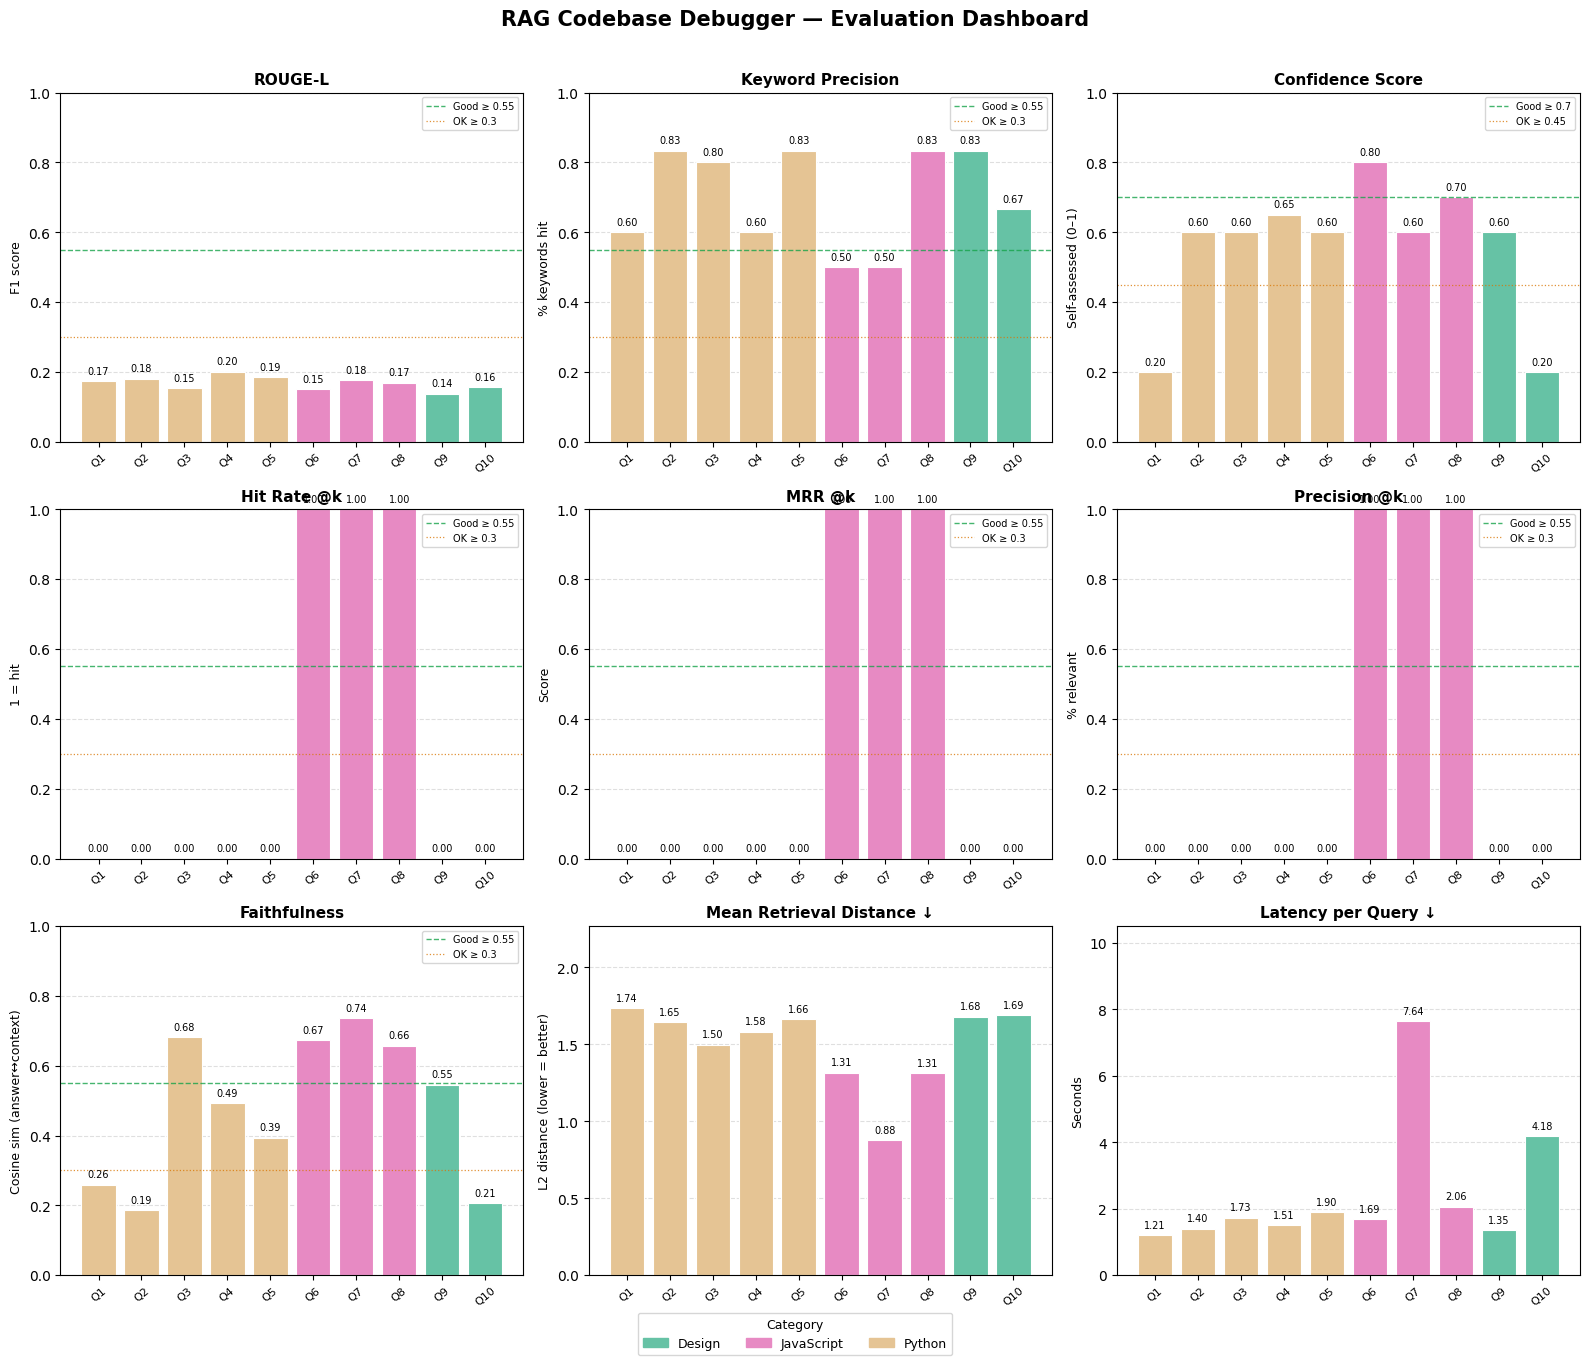

✅ Dashboard saved → /content/evaluation_dashboard.png

────────────────────────────────────────────────────────────────────────────────
  FULL RESULTS TABLE
────────────────────────────────────────────────────────────────────────────────
  Q   Category  ROUGE-L  KwPrec  HitRate   MRR  Prec@k  Faith  Conf ConfLbl  Words  Lat(s)
 Q1     Python    0.173   0.600    0.000 0.000   0.000  0.259 0.200     Low    217   1.210
 Q2     Python    0.181   0.833    0.000 0.000   0.000  0.186 0.600  Medium    269   1.400
 Q3     Python    0.153   0.800    0.000 0.000   0.000  0.681 0.600  Medium    342   1.730
 Q4     Python    0.201   0.600    0.000 0.000   0.000  0.492 0.650  Medium    251   1.510
 Q5     Python    0.186   0.833    0.000 0.000   0.000  0.394 0.600  Medium    323   1.900
 Q6 JavaScript    0.151   0.500    1.000 1.000   1.000  0.672 0.800    High    287   1.690
 Q7 JavaScript    0.176   0.500    1.000 1.000   1.000  0.735 0.600  Medium    317   7.640
 Q8 JavaScript    0.169   0.833   

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Visualise Evaluation Results (no radar chart)     ║
# ╚══════════════════════════════════════════════════════════════╝

def plot_evaluation_dashboard(results: List[EvalResult]) -> None:
    valid = [r for r in results if r.error is None]
    if not valid:
        print(f"{R}No valid results to plot.{RESET}")
        return

    labels     = [f"Q{i+1}" for i in range(len(valid))]
    categories = [r.category for r in valid]

    unique_cats = sorted(set(categories))
    palette     = plt.cm.Set2(np.linspace(0, 0.8, max(len(unique_cats), 3)))
    cat_colour  = {c: palette[i] for i, c in enumerate(unique_cats)}
    bar_colours = [cat_colour[c] for c in categories]

    # ── 3 rows × 3 cols = 9 charts ──────────────────────────────
    fig, axes = plt.subplots(3, 3, figsize=(16, 13))
    fig.suptitle(
        "RAG Codebase Debugger — Evaluation Dashboard",
        fontsize=15, fontweight="bold", y=1.01,
    )

    def bar_chart(ax, values, title, ylabel,
                  ylim=(0, 1), good_line=0.55, mid_line=0.30,
                  annotate=True, invert_good=False):
        """
        invert_good=True  → lower is better (distance, latency).
        good_line=None    → no threshold lines drawn.
        """
        bars = ax.bar(labels, values, color=bar_colours,
                      edgecolor="white", linewidth=0.8, zorder=2)
        ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_ylim(*ylim)
        ax.tick_params(axis="x", labelsize=8, rotation=40)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
        ax.set_axisbelow(True)

        if good_line is not None and not invert_good:
            ax.axhline(good_line, color="#16a34a", linestyle="--",
                       linewidth=1.0, alpha=0.8, label=f"Good ≥ {good_line}")
            ax.axhline(mid_line,  color="#d97706", linestyle=":",
                       linewidth=0.9, alpha=0.8, label=f"OK ≥ {mid_line}")
            ax.legend(fontsize=7, loc="upper right")

        if annotate:
            for bar, val in zip(bars, values):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + ylim[1] * 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7,
                )

    max_dist = max(r.mean_distance for r in valid)
    max_lat  = max(r.latency_s     for r in valid)
    max_wc   = max(r.word_count    for r in valid)

    # Row 0 — answer quality
    bar_chart(axes[0, 0], [r.rougeL        for r in valid], "ROUGE-L",            "F1 score")
    bar_chart(axes[0, 1], [r.keyword_prec  for r in valid], "Keyword Precision",  "% keywords hit")
    bar_chart(axes[0, 2], [r.confidence_score for r in valid],
              "Confidence Score", "Self-assessed (0–1)",
              good_line=0.70, mid_line=0.45)

    # Row 1 — retrieval quality
    bar_chart(axes[1, 0], [r.hit_rate   for r in valid], "Hit Rate @k",    "1 = hit")
    bar_chart(axes[1, 1], [r.mrr        for r in valid], "MRR @k",         "Score")
    bar_chart(axes[1, 2], [r.prec_at_k  for r in valid], "Precision @k",   "% relevant")

    # Row 2 — faithfulness + operational
    bar_chart(axes[2, 0], [r.faithfulness  for r in valid],
              "Faithfulness", "Cosine sim (answer↔context)")

    bar_chart(axes[2, 1], [r.mean_distance for r in valid],
              "Mean Retrieval Distance ↓", "L2 distance (lower = better)",
              ylim=(0, max_dist * 1.25 + 0.1),
              good_line=None, invert_good=True)

    bar_chart(axes[2, 2], [r.latency_s for r in valid],
              "Latency per Query ↓", "Seconds",
              ylim=(0, max_lat * 1.35 + 0.2),
              good_line=None, invert_good=True)

    # ── Category legend ──────────────────────────────────────────
    patches = [mpatches.Patch(color=cat_colour[c], label=c) for c in unique_cats]
    fig.legend(
        handles=patches, title="Category",
        loc="lower center", ncol=len(unique_cats),
        fontsize=9, title_fontsize=9,
        bbox_to_anchor=(0.5, -0.03),
    )

    plt.tight_layout()
    plt.savefig("/content/evaluation_dashboard.png", dpi=140,
                bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"{G}✅ Dashboard saved → /content/evaluation_dashboard.png{RESET}")

    # ── Summary results table ────────────────────────────────────
    df = pd.DataFrame([{
        "Q":        f"Q{i+1}",
        "Category": r.category,
        "ROUGE-L":  r.rougeL,
        "KwPrec":   r.keyword_prec,
        "HitRate":  r.hit_rate,
        "MRR":      r.mrr,
        "Prec@k":   r.prec_at_k,
        "Faith":    r.faithfulness,
        "Conf":     r.confidence_score,
        "ConfLbl":  r.confidence_label,
        "Words":    r.word_count,
        "Lat(s)":   r.latency_s,
    } for i, r in enumerate(valid)])

    print(f"\n{'─'*80}")
    print("  FULL RESULTS TABLE")
    print(f"{'─'*80}")
    print(df.to_string(index=False, float_format="{:.3f}".format))

    numeric_cols = ["ROUGE-L","KwPrec","HitRate","MRR","Prec@k","Faith","Conf","Words","Lat(s)"]
    print(f"\n  Overall averages:")
    for col in numeric_cols:
        print(f"    {col:<12}: {df[col].mean():.3f}")

    # ── Confidence label distribution ────────────────────────────
    print(f"\n  Confidence label distribution:")
    for lbl, count in df["ConfLbl"].value_counts().items():
        pct = count / len(df) * 100
        print(f"    {lbl:<10}: {count} queries ({pct:.0f}%)")


plot_evaluation_dashboard(eval_results)